# Deportation Data Project: ICE data

Data source: [Deportation Data Project](https://deportationdata.org/data/ice.html)

Our past story: [ICE arrests](https://coloradosun.com/2025/12/31/ice-arrests-2025-data-deportation-data-project/)

Related stories:

- [NYT interactive records](https://www.nytimes.com/interactive/2025/12/04/us/ice-arrests-criminal-records-data.html)
- [NYT interactive network](https://www.nytimes.com/interactive/2025/12/22/us/trump-immigration-deportation-network-ice-arrests.html)
- [CO Times Recorder about Aurora center](https://coloradotimesrecorder.com/2026/03/after-co-times-recorder-revealed-secret-detention-centers-in-co-27-lawmakers-call-on-ice-for-immediate-transparency/77113/)


In [37]:
import polars as pl  # polars is much faster than pandas for large data
from datetime import datetime
import matplotlib.pyplot as plt
from plotnine import ggplot, aes, geom_line, geom_bar, theme_minimal

from helpers import (
    read_data,
    read_calls_data,
    read_historical_data,
    clean_duplicates,
    confirm_state,
    state_from_landmark,
    state_from_docket,
    co_facilities,
    fbi_violent_crime,
    get_percent,
)

In [38]:
# TODO: I think we should start open-sourcing our methodology/scripts
# TODO: would data reading be faster if we specified columns?

# Data

## Arrests

Description:

> Records every time ICE arrests someone, whether or not that arrest results in a decision to detain the person; or issues a Notice to Appear (NTA), the document that starts a deportation case. Note that other agencies also issue NTAs, and those would not appear as arrests in this table. We treat "apprehensions," "arrests," and "administrative arrests" as synonyms.


In [39]:
arrests = read_data("arrests")

data\arrests-0326.xlsx


Could not determine dtype for column 1, falling back to string


(713464, 28)
['apprehension_aor', 'apprehension_criminality', 'apprehension_date', 'apprehension_date_time', 'apprehension_method', 'apprehension_site_landmark', 'apprehension_state', 'apprehension_type', 'arresting_agency', 'birth_year', 'case_category', 'case_criminality', 'case_status', 'case_threat_level', 'citizenship_country', 'departed_date', 'departure_country', 'duplicate_likely', 'file_original', 'final_order_date', 'final_order_yes_no', 'final_program', 'gender', 'operation', 'row_original', 'sheet_original', 'toa_current_duty_site', 'unique_identifier']


apprehension_date,apprehension_type,apprehension_state,apprehension_aor,final_program,arresting_agency,apprehension_method,apprehension_criminality,case_status,case_category,departure_country,final_order_yes_no,birth_year,citizenship_country,gender,departed_date,final_order_date,apprehension_site_landmark,operation,toa_current_duty_site,case_criminality,case_threat_level,unique_identifier,apprehension_date_time,duplicate_likely,file_original,sheet_original,row_original
date,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,datetime[ms],date,str,str,str,str,str,str,datetime[ms],bool,str,str,i64
2022-10-01,null,"""TEXAS""","""San Antonio Area of Responsibi…","""Non-Detained Docket Control""","""ICE""","""ERO Reprocessed Arrest""","""3 Other Immigration Violator""","""A-Proceedings Terminated""","""[8B] Excludable / Inadmissible…",null,"""NO""",1974,"""CUBA""","""Male""",null,null,"""WALKINS AT SAN ANTONIO""","""-""","""ERO - San Antonio, TX Field Of…","""3 Other Immigration Violator""","""NA""","""bad3911f91e15e59572fe96a226c1f…",2022-10-01 01:10:00,false,"""2026-ICLI-00005_Arrests_FY23_2…","""FY2023""",124239
2022-10-01,null,null,"""Phoenix Area of Responsibility""","""Detained Docket Control""","""ICE""","""ERO Reprocessed Arrest""","""1 Convicted Criminal""","""8-Excluded/Removed - Inadmissi…","""[8C] Excludable / Inadmissible…","""PERU""","""YES""",1970,"""PERU""","""Female""",2023-06-28 00:00:00,2023-05-31,null,null,"""ELOY, AZ, SERVICE PROCESSING C…","""1 Convicted Criminal""","""1""","""dafdb5d0e565d238b9093e99c42e30…",2022-10-01 01:47:37,false,"""2026-ICLI-00005_Arrests_FY23_2…","""FY2023""",145764
2022-10-01,null,null,"""Phoenix Area of Responsibility""","""Detained Docket Control""","""ICE""","""ERO Reprocessed Arrest""","""3 Other Immigration Violator""","""8-Excluded/Removed - Inadmissi…","""[8C] Excludable / Inadmissible…","""COLOMBIA""","""YES""",1984,"""COLOMBIA""","""Female""",2023-02-02 00:00:00,2023-01-18,null,null,"""ELOY, AZ, SERVICE PROCESSING C…","""3 Other Immigration Violator""","""NA""","""1db208374a6ce32dd03f1b6d876c9f…",2022-10-01 02:52:47,false,"""2026-ICLI-00005_Arrests_FY23_2…","""FY2023""",19899


### Cleaning

1. Filter for blanks in the Apprehension State field. If Apprehension Landmark Site appears to be in Colorado, update the Apprehension State accordingly.
   1. Note: facility is probably unrelated to apprehension - people have been sent to random facilities in other states.
2. Clean out states listed in the Apprehension State field and remove those that don't belong.
3. Search for duplicates on unique identifiers. If they occurred within a day or two get rid of the older one (often there's removal on one of them, keep that one). TODO: but isn't it meaningful that someone is arrested more than once?
   1. Changed to use the "duplicate_likely" column provided by Deportation Data Project
4. If you plan to compare across years, consider filtering prior years to only the dates available in the current year. For comparisons across administrations, keep in mind that Inauguration Day is January 20.


Appears to be a data issue with impossible date of arrest


In [40]:
arrests = arrests.with_columns(
    arrest_year=pl.col("apprehension_date_time").dt.year(),
    arrest_month=pl.col("apprehension_date_time").dt.month(),
    arrest_day=pl.col("apprehension_date_time").dt.day(),
)

display(arrests["arrest_year"].value_counts())
arrests["apprehension_date"].sort().value_counts()

arrest_year,count
i32,u32
2025,321701
2022,48629
2024,111223
2023,153426
2026,78485


apprehension_date,count
date,u32
2022-10-01,101
2022-10-02,80
2022-10-03,708
2022-10-04,809
2022-10-05,870
…,…
2026-03-08,540
2026-03-09,1056
2026-03-10,1258


In [41]:
arrests = clean_duplicates(
    arrests, id_col="unique_identifier", datetime_col="apprehension_date"
)

Records with missing ID: (0, 31)


In [42]:
print(arrests["apprehension_date"].min(), arrests["apprehension_date"].max())

2022-10-01 2026-09-17


## Detention stays

Description:

> Records each detention from book-in to book-out at a given detention center for a given individual; most individuals have more than one row in the table because they are transferred between detention centers. Individuals may also be detained more than once and therefore have more than one "stay" in detention. We explain further in the relevant field definitions.


In [43]:
stays = read_data(
    "detention-stays", schema_overrides={"initial_bond_set_date": pl.Date}
)

data\detention-stays-0326.xlsx


Could not determine dtype for column 38, falling back to string


(1087417, 64)
['birth_country', 'birth_year', 'bond_posted_amount', 'bond_posted_date', 'book_in_aor', 'book_in_criminality', 'book_in_date_time_first', 'book_in_date_time_last', 'book_in_date_time_longest', 'book_in_site', 'book_out_date_time_first', 'book_out_date_time_last', 'book_out_date_time_longest', 'case_category', 'case_ina_236c_yes_no', 'case_status', 'case_threat_level', 'citizenship_country', 'departed_date', 'departure_country', 'detainee_classification', 'detention_facility_code_first', 'detention_facility_code_last', 'detention_facility_code_longest', 'detention_facility_codes_all', 'detention_facility_first', 'detention_facility_last', 'detention_facility_longest', 'detention_release_reason', 'entry_date', 'entry_status', 'ethnicity', 'felon', 'final_charge', 'final_order_date', 'final_order_yes_no', 'final_program', 'gender', 'initial_bond_set_amount', 'initial_bond_set_date', 'known_terrorist_yes_no', 'marital_status', 'most_serious_conviction_code', 'msc_charge', 'm

stay_ID,n_stints,detention_facility_codes_all,unique_identifier,stay_book_in_date_time,stay_book_out_date_time,detention_release_reason,stay_book_out_date,stay_release_reason,religion,gender,marital_status,ethnicity,birth_country,citizenship_country,entry_status,known_terrorist_yes_no,suspected_gang_yes_no,msc_charge,msc_sentence_days,msc_sentence_months,msc_sentence_years,most_serious_conviction_code,felon,offense_ina_236c_yes_no,case_ina_236c_yes_no,bond_posted_date,bond_posted_amount,case_status,case_category,final_order_yes_no,final_order_date,case_threat_level,detainee_classification,final_charge,departed_date,departure_country,initial_bond_set_amount,initial_bond_set_date,birth_year,book_in_criminality,race,entry_date,final_program,msc_charge_date,msc_conviction_date,msc_criminal_charge_status,msc_criminal_charge_status_code,msc_crime_class,book_in_site,book_in_aor,n_stays,detention_facility_first,detention_facility_code_first,book_in_date_time_first,book_out_date_time_first,detention_facility_longest,detention_facility_code_longest,book_in_date_time_longest,book_out_date_time_longest,detention_facility_last,detention_facility_code_last,book_in_date_time_last,book_out_date_time_last
str,i64,str,str,datetime[ms],datetime[ms],str,date,str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,str,str,str,str,datetime[ms],i64,str,str,str,date,str,str,str,date,str,i64,date,i64,str,str,date,str,date,date,str,str,str,str,str,i64,str,str,datetime[ms],datetime[ms],str,str,datetime[ms],datetime[ms],str,str,datetime[ms],datetime[ms]
"""0000004d7b875782a3b6f2b460f98c…",3,"""AUSHOLD; CCAHUTX; IWAHOLD""","""0000004d7b875782a3b6f2b460f98c…",2025-11-16 12:58:00,2025-11-28 00:50:00,"""Removed""",2025-11-28,"""Removed""",null,"""Male""","""Unknown""","""Hispanic Origin""","""VENEZUELA""","""VENEZUELA""","""Not Applicable""","""NO""","""NO""",null,null,null,null,null,null,"""N""","""N""",null,null,"""8-Excluded/Removed - Inadmissi…","""[8C] Excludable / Inadmissible…","""YES""",2024-08-01,"""NA""","""Low""","""ALIEN PRESENT WITHOUT ADMISSIO…",2025-11-28,"""VENEZUELA""",null,null,1990,"""3 Other Immigration Violator""","""White""",2023-09-30,"""ERO Criminal Alien Program""",null,null,null,null,null,"""FLORENCE, AZ, SERVICE PROCESSI…","""Phoenix Area of Responsibility""",1,"""AUSTIN DRO HOLD ROOM""","""AUSHOLD""",2025-11-16 12:58:00,2025-11-16 16:27:00,"""T DON HUTTO DETENTION CENTER""","""CCAHUTX""",2025-11-16 16:41:00,2025-11-25 04:16:00,"""AZ REM OP COORD CENTER (AROCC)""","""IWAHOLD""",2025-11-26 22:15:00,2025-11-28 00:50:00
"""0000162b33f636fce8b114d00fa8d8…",2,"""BLBNATX; PRLDCTX""","""0000162b33f636fce8b114d00fa8d8…",2023-01-05 15:18:00,2023-02-27 01:31:00,"""Removed""",2023-02-27,"""Removed""",null,"""Female""","""Unknown""",null,"""COLOMBIA""","""COLOMBIA""","""PWA Mexico""","""NO""","""NO""",null,null,null,null,null,null,"""N""","""N""",null,null,"""8-Excluded/Deported/Removed""",null,"""YES""",2023-01-20,"""NA""","""Low""","""IMMIGRANT WITHOUT AN IMMIGRANT…",2023-02-27,"""COLOMBIA""",null,null,1985,"""3 Other Immigration Violator""","""White""",2022-12-31,"""Border Patrol""",null,null,null,null,null,"""Bluebonnet Detention Center""","""Dallas Area of Responsibility""",2,"""BLUEBONNET DET FCLTY""","""BLBNATX""",2023-01-05 15:18:00,2023-02-26 14:00:00,"""BLUEBONNET DET FCLTY""","""BLBNATX""",2023-01-05 15:18:00,2023-02-26 14:00:00,"""PRAIRIELAND DETENTION CENTER""","""PRLDCTX""",2023-02-26 20:44:00,2023-02-27 01:31:00
"""0000162b33f636fce8b114d00fa8d8…",1,"""STFRCTX""","""0000162b33f636fce8b114d00fa8d8…",2023-05-17 07:07:00,2023-10-24 12:45:00,"""Order of supervision""",2023-10-24,"""Order of supervision""",null,"""Female""","""Unknown""",null,"""COLOMBIA""","""COLOMBIA""","""PWA Mexico""","""NO""","""NO""",null,null,null,null,null,null,"""N""","""N""",null,null,"""ACTIVE""","""[16] Reinstated Final Order""","""YES""",2023-05-14,"""NA""","""Low""",null,null,null,null,null,1985,"""3 Other Immigration Violator""","""Black""",2023-05-12,

In [44]:
# this gets a list of the detention facilities
det_facility = stays.group_by(["detention_facility_first"]).agg(pl.len().alias("count"))
det_facility.write_csv("output/det_facility.csv")
det_facility

C:\Users\notka\AppData\Local\Temp\ipykernel_4716\1581357572.py:3: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("count")


detention_facility_first,count
str,u32
"""VAL VERDE DETENTION CENTER""",2473
"""SAN JUAN SUB-OFFICE HOLD ROOM""",460
"""SPRINGFIELD FED.MED.CNTR""",18
"""LA PAZ COUNTY ADULT DET. FAC.""",633
"""DEPT OF CORRECTIONS-HAGATNA""",165
…,…
"""SOUTH TEXAS/PEARSALL HOLD ROOM""",92
"""SHERIDAN FED.CORR.INST.""",1
"""FCI BERLIN""",4


In [45]:
# this uses the list of colorado facilities to extract the info from the larger detention facility list
co_detain = stays.filter(pl.col("detention_facility_first").is_in(co_facilities))
co_detain.write_csv("output/co_detain.csv")
co_detain.head()

stay_ID,n_stints,detention_facility_codes_all,unique_identifier,stay_book_in_date_time,stay_book_out_date_time,detention_release_reason,stay_book_out_date,stay_release_reason,religion,gender,marital_status,ethnicity,birth_country,citizenship_country,entry_status,known_terrorist_yes_no,suspected_gang_yes_no,msc_charge,msc_sentence_days,msc_sentence_months,msc_sentence_years,most_serious_conviction_code,felon,offense_ina_236c_yes_no,case_ina_236c_yes_no,bond_posted_date,bond_posted_amount,case_status,case_category,final_order_yes_no,final_order_date,case_threat_level,detainee_classification,final_charge,departed_date,departure_country,initial_bond_set_amount,initial_bond_set_date,birth_year,book_in_criminality,race,entry_date,final_program,msc_charge_date,msc_conviction_date,msc_criminal_charge_status,msc_criminal_charge_status_code,msc_crime_class,book_in_site,book_in_aor,n_stays,detention_facility_first,detention_facility_code_first,book_in_date_time_first,book_out_date_time_first,detention_facility_longest,detention_facility_code_longest,book_in_date_time_longest,book_out_date_time_longest,detention_facility_last,detention_facility_code_last,book_in_date_time_last,book_out_date_time_last
str,i64,str,str,datetime[ms],datetime[ms],str,date,str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,str,str,str,str,datetime[ms],i64,str,str,str,date,str,str,str,date,str,i64,date,i64,str,str,date,str,date,date,str,str,str,str,str,i64,str,str,datetime[ms],datetime[ms],str,str,datetime[ms],datetime[ms],str,str,datetime[ms],datetime[ms]
"""00082e2e682f5c8c10b48b2252eeb0…",1,"""DENICDF""","""00082e2e682f5c8c10b48b2252eeb0…",2024-03-07 19:27:00,2024-04-12 15:56:00,"""Order of supervision""",2024-04-12,"""Order of supervision""",null,"""Male""","""Unknown""",null,"""VENEZUELA""","""VENEZUELA""","""PWA Mexico""","""NO""","""NO""",null,null,null,null,null,null,"""N""","""N""",null,null,"""ACTIVE""",null,"""YES""",2024-04-05,"""NA""","""Low""",null,null,null,null,null,2005,"""3 Other Immigration Violator""","""White""",2024-02-27,"""Border Patrol""",null,null,null,null,null,"""ERO - CDF Denver, CO Sub-Offic…","""Denver Area of Responsibility""",1,"""DENVER CONTRACT DETENTION FACI…","""DENICDF""",2024-03-07 19:27:00,2024-04-12 15:56:00,"""DENVER CONTRACT DETENTION FACI…","""DENICDF""",2024-03-07 19:27:00,2024-04-12 15:56:00,"""DENVER CONTRACT DETENTION FACI…","""DENICDF""",2024-03-07 19:27:00,2024-04-12 15:56:00
"""000d54bf8d6566d30b964ae0c285a6…",1,"""DENICDF""","""000d54bf8d6566d30b964ae0c285a6…",2023-08-12 14:00:00,2023-08-31 10:00:00,"""Order of recognizance""",2023-08-31,"""Order of recognizance""",null,"""Male""","""Single""",null,"""SENEGAL""","""SENEGAL""","""PWA Mexico""","""NO""","""NO""",null,null,null,null,null,null,"""N""","""N""",null,null,"""ACTIVE""","""[8A] Excludable / Inadmissible…","""NO""",null,"""NA""","""Low""",null,null,null,null,null,1994,"""3 Other Immigration Violator""","""Black""",2023-08-07,"""Border Patrol""",null,null,null,null,null,"""ERO - CDF Denver, CO Sub-Offic…","""Denver Area of Responsibility""",1,"""DENVER CONTRACT DETENTION FACI…","""DENICDF""",2023-08-12 14:00:00,2023-08-31 10:00:00,"""DENVER CONTRACT DETENTION FACI…","""DENICDF""",2023-08-12 14:00:00,2023-08-31 10:00:00,"""DENVER CONTRACT DETENTION FACI…","""DENICDF""",2023-08-12 14:00:00,2023-08-31 10:00:00
"""001836af46acc11e6d28d0f7ed0a4b…",2,"""DENICDF; DENICDF""","""001836af46acc11e6d28d0f7ed0a4b…",2023-09-01 16:48:00,2023-10-20 13:19:00,"""Order of recognizance""",2023-10-20,"""Order of recognizance""",null,"""Male""","""Single""",null,"""SENEGAL""","""SENEGAL""","""Not Applicable""","""NO""","""NO""",null,null,null,null,null,null,"""N""","""N""",null,null,"""ACTIVE""","""[8B] Excludable / Inadmissible…","""NO""",null,"""NA""","""Low""",null,null,null,null,null,2000,"""3 Other Immigration Violator""","""Black""",2023-08-27,"""ERO Criminal Alien Program""",null,null,null,null,null,"""ERO - CDF Denver, CO Sub-Offic…","""Denver Area of Responsibili

## Detention stints

Description:

> Individual book-ins to each detention facility (multiple per stay when detainees are transferred). We recommend using the detention stays dataset for most detention analyses at the individual level. For analyses at the detention facility level, by contrast, we recommend using the detention stints dataset. Note that filtering by stint can lead to inaccurate individual-level inferences, since a single person may appear across multiple stints when transferred between facilities.


In [ ]:
stints = read_data(
    "detention-stints",
    schema_overrides={
        "initial_bond_set_date": pl.Date,
        "initial_bond_set_amount": pl.String,
        "bond_posted_date": pl.String,
        "bond_posted_amount": pl.String,
        "final_order_date": pl.String,
        "likely_duplicate": pl.String,
    },
)

## 911 calls


In [ ]:
firecalls = read_calls_data("calls-afr")
pdcalls = read_calls_data("calls-apd")

## Historical data

We did not end up using these data because they are too difficult to clean and understand confidently.


In [46]:
# hd1 = read_historical_data(
#     "ERO Apprehension",
#     header_row=4,
#     schema_overrides={"Fugitive as of Date": pl.Datetime, "Departed Date": pl.Datetime},
# )

In [47]:
# h2 = read_historical_data(
#     "Redacted",
#     header_row=6,
#     drop_cols=[
#         "ARREST MOST SERIOUS CONVICTION DATE_1",
#         "EID PERS ID",
#         "ARREST MOST SERIOUS CONVICTION CHARGE DATE_1",
#         "ARREST MOST SERIOUS PENDING CRIMINAL CHARGE CATEGORY",
#     ],
# )

In [48]:
# all years, but no state info - cannot use
mapping = {"Arrested Created By": "Arrest Created By"}

# h3 = read_data(
#     "Redacted_raw.xlsx",
#     header_row=5,
#     rename_map=mapping,
# )

In [49]:
# hd4 = read_data(
#     "UN",
#     schema_overrides={"Departed Date": pl.Datetime},
#     header_row=5,
#     rename_map=mapping,
#     drop_cols=["Removal Threat Level", "Case Closed Date"],
# )

We can concatenate the datasets because the end of the historical dataset exactly coincides with the start of the next.


In [50]:
# print(hd1["Apprehension Date And Time"].min(), hd1["Apprehension Date And Time"].max())

### Cleaning

Remove duplicates if within 24 hours of each other

TODO: look at their code for detecting duplicates


In [51]:
# # I don't want to drop a third of the dataset, but it's hard to tell which are duplicates...
# hd1 = clean_duplicates(hd1)

# # ensure no overlap with next set
# hd1 = hd1.filter(pl.col("apprehension_date") < pl.date(2022, 10, 1))

In [52]:
# no id col provided for hd2

In [53]:
# hd3 = clean_duplicates(
#     hd3, id_col="Anonymized Identifier", datetime_col="Apprehension Date"
# )

In [54]:
# no id col provided for hd4

## Construct full dataset


In [55]:
# most accurate information is most recent
# keep one row per unique person and their MSC
charge = (
    stays.filter(pl.col("msc_charge").is_not_null())
    .sort("stay_book_out_date_time")
    .unique(subset=["unique_identifier"], keep="last")[
        ["unique_identifier", "msc_charge"]
    ]
)

In [56]:
# arrests with Denver area of responsibility AND state of Colorado
co_arrests = arrests.filter(confirm_state(arrests) | state_from_landmark(arrests))

print(co_arrests.shape)
display(co_arrests.group_by("arrest_year").agg(pl.len()).sort("arrest_year"))
co_arrests.head(3)

Likely to be CO 2891
(10305, 31)


C:\Users\notka\AppData\Local\Temp\ipykernel_4716\2992487658.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  display(co_arrests.group_by("arrest_year").agg(pl.count()).sort("arrest_year"))


arrest_year,count
i32,u32
2022,1062
2023,3181
2024,1089
2025,4161
2026,812


apprehension_date,apprehension_type,apprehension_state,apprehension_aor,final_program,arresting_agency,apprehension_method,apprehension_criminality,case_status,case_category,departure_country,final_order_yes_no,birth_year,citizenship_country,gender,departed_date,final_order_date,apprehension_site_landmark,operation,toa_current_duty_site,case_criminality,case_threat_level,unique_identifier,apprehension_date_time,duplicate_likely,file_original,sheet_original,row_original,arrest_year,arrest_month,arrest_day
date,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,datetime[ms],date,str,str,str,str,str,str,datetime[ms],bool,str,str,i64,i32,i8,i8
2022-10-03,null,"""COLORADO""","""Denver Area of Responsibility""","""Non-Detained Docket Control""","""ICE""","""Non-Custodial Arrest""","""3 Other Immigration Violator""","""8-Excluded/Removed - Inadmissi…","""[8C] Excludable / Inadmissible…","""NICARAGUA""","""YES""",1982,"""NICARAGUA""","""Male""",2023-12-04 00:00:00,2024-04-09,"""DENVER COUNTY""",null,"""DENVER, CO, DOCKET CONTROL OFF…","""3 Other Immigration Violator""","""NA""","""43577fc1b4a536f21878a1dcd45f31…",2022-10-03 10:11:00,false,"""2026-ICLI-00005_Arrests_FY23_2…","""FY2023""",44857,2022,10,3
2022-10-03,null,"""COLORADO""","""Denver Area of Responsibility""","""Non-Detained Docket Control""","""ICE""","""Non-Custodial Arrest""","""3 Other Immigration Violator""","""A-Proceedings Terminated""","""[8B] Excludable / Inadmissible…",null,"""NO""",2006,"""CUBA""","""Female""",null,null,"""FREMONT COUNTY, COLORADO""",null,"""ERO - Pueblo, CO Sub-Office""","""3 Other Immigration Violator""","""NA""","""af65d352589cd160eb10afbebfbbdc…",2022-10-03 10:42:00,false,"""2026-ICLI-00005_Arrests_FY23_2…","""FY2023""",116641,2022,10,3
2022-10-03,null,"""COLORADO""","""Denver Area of Responsibility""","""Non-Detained Docket Control""","""ICE""","""Non-Custodial Arrest""","""3 Other Immigration Violator""","""A-Proceedings Terminated""","""[8B] Excludable / Inadmissible…",null,"""NO""",1984,"""CUBA""","""Female""",null,null,"""FREMONT COUNTY, COLORADO""",null,"""ERO - Pueblo, CO Sub-Office""","""3 Other Immigration Violator""","""NA""","""535598ea1a3aa1bee3602c43be059b…",2022-10-03 10:44:00,false,"""2026-ICLI-00005_Arrests_FY23_2…","""FY2023""",55419,2022,10,3


In [57]:
# filter to dates of interest
# not using 2023 data because of the large number of missing values for apprehension state
co_all = co_arrests.filter(pl.col("apprehension_date") >= pl.date(2024, 1, 1)).join(
    charge, on="unique_identifier", how="left"
)[
    "unique_identifier",
    "apprehension_date",
    "apprehension_criminality",
    "apprehension_method",
    "arrest_day",
    "arrest_month",
    "arrest_year",
    "msc_charge",
]

print(co_all.shape)
co_all.write_csv("output/co_all.csv")

(6062, 8)


In [58]:
# # exploratory - not used
# co_hist = hd1.with_columns(
#     apprehension_state=pl.when(
#         state_from_landmark(
#             hd1,
#             aor_col="Apprehension AOR",
#             landmark_col="Apprehension Landmark"
#         ) | state_from_docket(hd1, toa_col="Physical Site",)
#     )
#     .then(pl.lit("COLORADO"))
#     .otherwise(pl.col("State"))
# ).filter(pl.col("apprehension_state") == "COLORADO")

# print("Records in CO", co_hist.shape)
# co_hist.write_csv("output/co_hist.csv")
# co_hist.group_by("arrest_year").agg(pl.len())

# co_hist = co_hist.with_columns(
#     unique_identifier=pl.col("Sequence Number/Unique Identifier").cast(pl.String),
#     msc_charge=pl.col("Most Serious Criminal Conviction"),
#     apprehension_criminality=pl.when(
#         pl.col("Most Serious Criminal Conviction").is_not_null()
#     )
#     .then(pl.lit("1 Convicted Criminal"))
#     .when(pl.col("Most Serious Criminal Charge").is_not_null())
#     .then(pl.lit("2 Pending Criminal Charges"))
#     .otherwise(pl.lit("3 Other Immigration Violator")),
#     apprehension_method=pl.col("Apprehension Method"),
# )
# print(co_hist["apprehension_criminality"].value_counts())
# print(co_arrests["apprehension_criminality"].value_counts())


# Analysis

Possible additional analyses: gender, age; citizenship, third country deportations
Fish's idea about which days there weren't any arrests, pulling out holidays


In [59]:
co_all = pl.read_csv("output/co_all.csv").with_columns(
    apprehension_date=pl.col("apprehension_date").str.strptime(pl.Date, "%Y-%m-%d")
)

## Number of arrests

Running average to make trend more coherent.


For comparing to prior year, ensure that data for prior year up to current month is kept


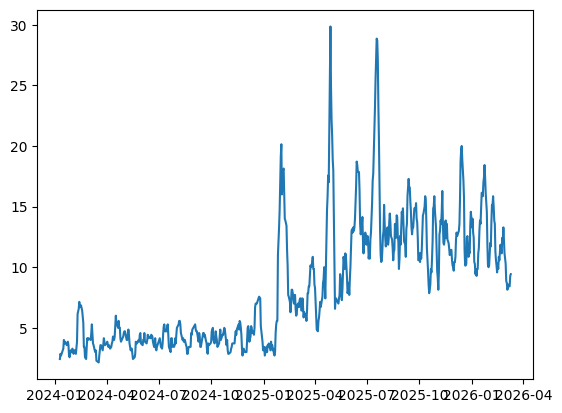

In [60]:
by_date = (
    co_all["apprehension_date"]
    .value_counts()
    .sort("apprehension_date")
    .with_columns(average=pl.col("count").fill_null(0).rolling_mean(window_size=7))[
        "average", "apprehension_date"
    ]
)

by_date.write_csv(f"output/by_date_{datetime.today().year}.csv")
by_date.sort("apprehension_date")["apprehension_date"].to_list()

plt.plot(by_date["apprehension_date"], by_date["average"])
# TODO: affected by CBP numbers so should take that out somehow, but CBP data not published yet

In [61]:
# get the first two years of the past administrations
by_admin = co_all.filter(
    co_all["arrest_year"].is_in([2017, 2018, 2021, 2022, 2025, 2026])
    & (
        # odd years are complete except for inauguration day
        (co_all["arrest_year"] % 2 == 1)
        & ~((co_all["arrest_month"] == 1) & (co_all["arrest_day"] < 20))
        | (
            # even years are only complete through the max month/day available in current dataset
            (co_all["arrest_year"] % 2 == 0)
            & (co_all["arrest_month"] == co_all["apprehension_date"].max().month)
            & (co_all["arrest_day"] <= co_all["apprehension_date"].max().day)
        )
    )
).with_columns(
    admin_month=pl.col("arrest_month").cast(pl.Int32)
    + (12 * (1 - pl.col("arrest_year").cast(pl.Int32) % 2))
)

print(
    by_admin[["arrest_year", "apprehension_date", "admin_month"]]
    .sort("admin_month")
    .unique("admin_month")
)

# recode
by_admin = by_admin.with_columns(
    admin=pl.when(pl.col("arrest_year").is_in([2017, 2018]))
    .then(pl.lit("First Trump"))
    .when(pl.col("arrest_year").is_in([2021, 2022]))
    .then(pl.lit("Biden"))
    .otherwise(pl.lit("Second Trump"))
)

# each record is an arrest for a unique person
by_admin = by_admin.group_by(["admin", "admin_month"]).agg(pl.len())
by_admin = by_admin.sort(["admin", "admin_month"]).with_columns(
    cumsum=pl.col("len").fill_null(0).cum_sum().over("admin")
)

by_admin = by_admin.pivot(index=["admin_month"], columns="admin", values="cumsum")

by_admin.write_csv(f"output/by_admin_{datetime.today().year}.csv")
by_admin.sort("admin_month")

shape: (13, 3)
┌─────────────┬───────────────────┬─────────────┐
│ arrest_year ┆ apprehension_date ┆ admin_month │
│ ---         ┆ ---               ┆ ---         │
│ i64         ┆ date              ┆ i32         │
╞═════════════╪═══════════════════╪═════════════╡
│ 2025        ┆ 2025-01-20        ┆ 1           │
│ 2025        ┆ 2025-02-01        ┆ 2           │
│ 2025        ┆ 2025-03-01        ┆ 3           │
│ 2025        ┆ 2025-04-01        ┆ 4           │
│ 2025        ┆ 2025-05-01        ┆ 5           │
│ …           ┆ …                 ┆ …           │
│ 2025        ┆ 2025-09-01        ┆ 9           │
│ 2025        ┆ 2025-10-01        ┆ 10          │
│ 2025        ┆ 2025-11-01        ┆ 11          │
│ 2025        ┆ 2025-12-01        ┆ 12          │
│ 2026        ┆ 2026-03-01        ┆ 15          │
└─────────────┴───────────────────┴─────────────┘


C:\Users\notka\AppData\Local\Temp\ipykernel_4716\1964051771.py:36: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  by_admin = by_admin.group_by(["admin", "admin_month"]).agg(pl.count())
C:\Users\notka\AppData\Local\Temp\ipykernel_4716\1964051771.py:41: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  by_admin = by_admin.pivot(index=["admin_month"], columns="admin", values="cumsum")


admin_month,Second Trump
i32,u32
1,170
2,406
3,634
4,971
5,1209
…,…
9,2949
10,3329
11,3684


In [62]:
totals = co_all.group_by("arrest_year").agg(pl.len())
totals.write_csv(f"output/totals_{datetime.today().year}.csv")
totals.sort("arrest_year")

C:\Users\notka\AppData\Local\Temp\ipykernel_4716\3656727717.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  totals = co_all.group_by("arrest_year").agg(pl.count())


arrest_year,count
i64,u32
2024,1089
2025,4161
2026,812


## Criminality

No date restrictions applied because this is a percentage analysis, which is comparable across years.


In [63]:
crim = co_all.with_columns(
    apprehension_criminality=pl.col("apprehension_criminality").str.replace(r"\d ", "")
)

crim = get_percent(crim, "arrest_year", "apprehension_criminality")

crim.write_csv(f"output/by_criminality_{datetime.today().year}.csv")
crim

arrest_year,Other Immigration Violator,Pending Criminal Charges,Convicted Criminal
i64,f64,f64,f64
2025,75.5,69.7,62.1
2024,8.6,16.0,27.1
2026,15.9,14.3,10.7


## MSC (most serious charge)

Bar chart with percentages. For this one, I am not excluding dates since percentages are comparable.

- find list of top 5 crimes since Trump's inauguration


In [64]:
# adds most serious conviction information, if present, to the arrests table
arrests_with_charge = co_all.filter(
    co_all["apprehension_criminality"].str.contains("Convicted")
)[
    [
        "unique_identifier",
        "msc_charge",
        "apprehension_date",
        "arrest_year",
        "arrest_month",
        "arrest_day",
    ]
]
print(arrests_with_charge.shape)
print("Top charges:")
display(
    arrests_with_charge.filter(pl.col("apprehension_date") > pl.date(2025, 1, 20))[
        "msc_charge"
    ]
    .value_counts()
    .sort("count", descending=True)
    .head(5)
)

(2421, 6)
Top charges:


msc_charge,count
str,u32
"""Driving Under Influence Liquor""",328
"""Assault""",237
"""Traffic Offense""",149
"""Illegal Entry (INA SEC.101(a)(…",96
"""Dangerous Drugs""",91


In [65]:
arrests_with_charge = arrests_with_charge.with_columns(
    violent=pl.when(pl.col("msc_charge").is_in(fbi_violent_crime).fill_null(False))
    .then(pl.lit("Violent"))
    .otherwise(pl.lit("Non-violent"))
)

arrests_with_charge = get_percent(arrests_with_charge, "arrest_year", "violent")

arrests_with_charge.write_csv("output/arrests_charges.csv")
arrests_with_charge.sort("arrest_year")

arrest_year,Violent,Non-violent
i64,f64,f64
2024,45.7,25.8
2025,45.1,63.4
2026,9.1,10.9


In [66]:
# 17 of the people with no charge have an MSC listed - this is likely charged but not convicted
# TODO: see if the team generated the msc_charge column and if so how
charge.join(
    co_all.filter(pl.col("apprehension_criminality").str.contains("Other")),
    on="unique_identifier",
    how="inner",
)[["apprehension_criminality", "apprehension_date", "msc_charge"]]

apprehension_criminality,apprehension_date,msc_charge
str,date,str
"""3 Other Immigration Violator""",2024-01-16,"""Larceny"""
"""3 Other Immigration Violator""",2025-01-26,"""Illegal Re-Entry (INA SEC.101(…"
"""3 Other Immigration Violator""",2025-08-11,"""Illegal Entry (INA SEC.101(a)(…"
"""3 Other Immigration Violator""",2025-09-22,"""Carrying Prohibited Weapon"""
"""3 Other Immigration Violator""",2024-11-06,"""Drug Trafficking"""
…,…,…
"""3 Other Immigration Violator""",2024-08-23,"""Synthetic Narcotic - Sell"""
"""3 Other Immigration Violator""",2025-04-27,"""Illegal Entry (INA SEC.101(a)(…"
"""3 Other Immigration Violator""",2025-01-30,"""Illegal Entry (INA SEC.101(a)(…"


## Length of detention stays over time

Due 20, due to run Memorial weekend
Aurora Detention Center operated by Geogroup

- shadowed people who were recently released
- DDP stays in "DENVER CONTRACT DETENTION FACILITY" check to see if aurora

Deliverables:

- rq1 + chart: length of stay over time, as far back as we can go
- rq2 + chart: anecdotally, fewer people are being released than are entering the facility?? monthly people in and out - is it possible to see if people were released
- colorado times recorder - able to see how long people were there - did they use a different data set

Questions:

- When did this facility open?


In [ ]:
aurora = (
    stints.filter(pl.col("detention_facility") == "DENVER CONTRACT DETENTION FACILITY")
    .filter(
        pl.col("stay_book_in_date_time") > pl.date(2022, 1, 1)
    )  # only 15 people were booked in 2022
    .with_columns(
        stint_len=pl.col("stay_book_out_date_time") - pl.col("stay_book_in_date_time"),
        stay_book_in_year=pl.col("stay_book_in_date_time").dt.year(),
        stay_book_in_month=pl.col("stay_book_in_date_time").dt.month(),
        stay_book_in_date=pl.col("stay_book_in_date_time").dt.date(),
        stay_book_out_date=pl.col("stay_book_out_date_time").dt.date(),
    )
    .with_columns(
        stint_days=(pl.col("stint_len") / pl.duration(days=1)).round(),
        stay_book_in_year_month=pl.col("stay_book_in_year").cast(pl.String)
        + "-"
        + pl.col("stay_book_in_month").cast(pl.String).str.zfill(2),
    )
    .sort("stint_len", descending=False)
    # remove duplicates
    .unique("unique_identifier", keep="first")
)

aurora["stay_book_in_year"].value_counts().sort("stay_book_in_year")

In [ ]:
# check that data is ordered
aurora.filter(pl.col("stay_book_out_date_time") < pl.col("stay_book_in_date_time"))

In [ ]:
# 6 people stayed shorter than an hour
aurora.filter(pl.col("stint_len") < pl.duration(hours=1))

In [ ]:
plt.plot(
    aurora["stint_days"].value_counts().sort("stint_days")["stint_days"],
    aurora["stint_days"].value_counts().sort("stint_days")["count"],
)

In [ ]:
plt.plot(
    aurora.sort("stay_book_in_date_time")["stay_book_in_date_time"],
    aurora.sort("stay_book_in_date_time")["stint_days"],
)

In [ ]:
by_date = aurora.with_columns(
    average=pl.col("stint_days").fill_null(0).rolling_mean(window_size=7)
).sort("stay_book_in_date")["average", "stay_book_in_date"]
plt.plot(by_date["stay_book_in_date"], by_date["average"])

In [ ]:
# number of people checking in per day
checkins = (
    aurora.group_by("stay_book_in_date")
    .agg(count=pl.len().cast(pl.Int64))
    .sort("stay_book_in_date")
)
plt.plot(checkins["stay_book_in_date"], checkins["count"])

In [ ]:
# number of people checking out per day
checkouts = (
    aurora.group_by("stay_book_out_date")
    .agg(count=pl.len().cast(pl.Int64))
    .sort("stay_book_out_date")
).with_columns()
plt.plot(checkouts["stay_book_out_date"], checkouts["count"])

In [ ]:
by_date

In [ ]:
stints["detention_release_reason"].value_counts().sort("count", descending=True)

In [ ]:
# net of people checking in per day

net_checkins = checkins.join(
    checkouts, left_on="stay_book_in_date", right_on="stay_book_out_date"
).with_columns(
    net=pl.col("count") - pl.col("count_right")  # net checkins minus checkouts per day
)

net_checkins = net_checkins.with_columns(
    stay_book_in_month=pl.col("stay_book_in_date").dt.year().cast(pl.String)
    + "-"
    + pl.col("stay_book_in_date").dt.month().cast(pl.String).str.zfill(2)
).sort("stay_book_in_date")

rolling = net_checkins.with_columns(average=pl.col("net").rolling_mean(window_size=7))[
    "average", "stay_book_in_date"
]

# plt.plot(rolling["stay_book_in_date"], rolling["average"])

total = (
    net_checkins.group_by("stay_book_in_month")
    .agg(total=pl.sum("net"))
    .sort("stay_book_in_month")
)
plt.bar(
    total["stay_book_in_month"],
    total["total"],
)

In [ ]:
# net of people checking in per day, for only nontransfers

# number of people checking out per day
checkouts2 = (
    aurora.filter(pl.col("detention_release_reason") != "Transferred")
    .group_by("stay_book_out_date")
    .agg(count=pl.len().cast(pl.Int64))
    .sort("stay_book_out_date")
)

net_checkins = checkins.join(
    checkouts2, left_on="stay_book_in_date", right_on="stay_book_out_date"
).with_columns(
    net=pl.col("count") - pl.col("count_right")  # net checkins minus checkouts per day
)

net_checkins2 = (
    net_checkins.with_columns(
        stay_book_in_month=pl.col("stay_book_in_date").dt.year().cast(pl.String)
        + "-"
        + pl.col("stay_book_in_date").dt.month().cast(pl.String).str.zfill(2)
    )
    .filter(pl.col("stay_book_in_month").is_not_null())
    .group_by("stay_book_in_month")
    .agg(pl.col("net").sum())
    .sort("stay_book_in_month")
)

plt.bar(net_checkins2["stay_book_in_month"], net_checkins2["net"])
net_checkins2

In [ ]:
by_month = (
    aurora.group_by("stay_book_in_year_month")
    .agg(pl.col("stint_days").mean())
    .sort("stay_book_in_year_month")
)
plt.bar(by_month["stay_book_in_year_month"], by_month["stint_days"])

In [ ]:
stays.filter(pl.col("detention_facility_first") == "DENVER CONTRACT DETENTION FACILITY")

In [ ]:
firecalls.columns

In [ ]:
firecalls["CALLTYPE"].unique().sort().to_list()

In [ ]:
firecalls["call_type_short"].unique().sort().to_list()

In [ ]:
by_date = (
    firecalls.with_columns(
        month=pl.col("DATE").dt.month().cast(pl.String).str.zfill(2)
        + "-"
        + pl.col("DATE").dt.year().cast(pl.String)
    )
    .group_by(["call_type_short", "month"])
    .agg(pl.len().alias("count"))
    .sort("month")
)
display(by_date)
display(
    firecalls.with_columns(year=pl.col("DATE").dt.year())["year"]
    .value_counts()
    .sort("year")
)
(
    ggplot(
        by_date,
        aes(x="month", y="count", group="call_type_short", color="call_type_short"),
    )
    + geom_line()
    + theme_minimal()
)


In [ ]:
# net of people checking in per day

net_checkins = checkins.join(
    checkouts, left_on="stay_book_in_date", right_on="stay_book_out_date"
).with_columns(
    net=pl.col("count") - pl.col("count_right")  # net checkins minus checkouts per day
)

net_checkins = net_checkins.with_columns(
    stay_book_in_month=pl.col("stay_book_in_date").dt.year().cast(pl.String)
    + "-"
    + pl.col("stay_book_in_date").dt.month().cast(pl.String).str.zfill(2)
).sort("stay_book_in_date")

rolling = net_checkins.with_columns(average=pl.col("net").rolling_mean(window_size=7))[
    "average", "stay_book_in_date"
]

# plt.plot(rolling["stay_book_in_date"], rolling["average"])

total = (
    net_checkins.group_by("stay_book_in_month")
    .agg(total=pl.sum("net"))
    .sort("stay_book_in_month")
)
plt.bar(
    total["stay_book_in_month"],
    total["total"],
)

In [ ]:
# net of people checking in per day

net_checkins = checkins.join(
    checkouts, left_on="stay_book_in_date", right_on="stay_book_out_date"
).with_columns(
    net=pl.col("count") - pl.col("count_right")  # net checkins minus checkouts per day
)

net_checkins = net_checkins.with_columns(
    stay_book_in_month=pl.col("stay_book_in_date").dt.year().cast(pl.String)
    + "-"
    + pl.col("stay_book_in_date").dt.month().cast(pl.String).str.zfill(2)
).sort("stay_book_in_date")

rolling = net_checkins.with_columns(average=pl.col("net").rolling_mean(window_size=7))[
    "average", "stay_book_in_date"
]

# plt.plot(rolling["stay_book_in_date"], rolling["average"])

total = (
    net_checkins.group_by("stay_book_in_month")
    .agg(total=pl.sum("net"))
    .sort("stay_book_in_month")
)
plt.bar(
    total["stay_book_in_month"],
    total["total"],
)

## 911 calls

No due date, ASAP

- 911 calls for fire and police from Aurora facility
  - priority: which calls to find out more about
- WaPo use of force matching
- have the calls increased over time and what are the patterns for types of calls
- ID is call number
  - remove duplicate rows - printer caused

Questions
- how do we want to categorize calls?
- what do some of these mean?


In [ ]:
pdcalls["CALLTYPE"].unique().sort().to_list()

In [ ]:
by_date = (
    pdcalls.with_columns(
        month=pl.col("DATE").dt.month().cast(pl.String).str.zfill(2)
        + "-"
        + pl.col("DATE").dt.year().cast(pl.String)
    )
    .group_by(["call_type_short", "month"])
    .agg(pl.len().alias("count"))
    .sort("month")
)
pdcalls.with_columns(year=pl.col("DATE").dt.year())["year"].value_counts().sort("year")

display(
    pdcalls.with_columns(year=pl.col("DATE").dt.year())["year"]
    .value_counts()
    .sort("year")
)
(
    ggplot(
        by_date,
        aes(x="month", y="count", group="call_type_short", color="call_type_short"),
    )
    + geom_line()
    + theme_minimal()
)


In [ ]:
display(firecalls["call_type_short"].value_counts().sort("count", descending=True))
display(firecalls["CALLTYPE"].value_counts().sort("count", descending=True))

In [ ]:
display(pdcalls["call_type_short"].value_counts().sort("count", descending=True))
display(pdcalls["CALLTYPE"].value_counts().sort("count", descending=True))

# Unused datasets (holdover from last story)

## Detainers

From the description: "Records all requests to state, county, and municipal jails and prisons either for a person to be held on a detainer or for a notification of release date and time. A detainer is a request to a local jail to hold someone for 48 hours beyond when they otherwise would be released so that ICE can make an arrest in the jail while the individual remains detained."


In [67]:
# detainer = read_data("detainer")

In [68]:
# felon_lookup = detainer[
#     [
#         "Unique Identifier",
#         "MSC Conviction Date",
#         "Detention Facility",
#         "Facility State",
#         "Prior Felony Yes No",
#         "Violent Misdemeanor Yes No",
#         "Aggravated Felony Yes No",
#     ]
# ].drop_duplicates(subset="Unique Identifier")
# felon_lookup.head()

In [69]:
# # this adds more information about conviction date, facility and more; mostly used the conviction date
# arrests_supplement = arrests_with_charge.merge(
#     felon_lookup, on="Unique Identifier", how="left"
# )
# arrests_supplement.write_csv("output/arrests_plus.csv")
# arrests_supplement.head()


In [70]:
# detainer.group_by(["Facility AOR"]).size().reset_index(name="counts")

In [71]:
# detainer.group_by(["Facility State"]).size().reset_index(name="counts")

In [72]:
# co_detainer = detainer[
#     (detainer["Facility AOR"] == "Denver Area of Responsibility")
#     | (detainer["Facility State"] == "Colorado")
#     # | (detainer["Facility State"] == "Wyoming")
# ]
# co_detainer.head()
# co_detainer.write_csv("output/co_wyo_detainer.csv")

## Removals

From the description: "Records every deportation that ICE conducts, with a row for each individual deportation. An individual only has more than one row if that individual was deported more than once. Note that expulsions may occur directly at the border, by CBP, without involving ICE."


In [73]:
# removals = read_data("removals")

In [74]:
# co__wyo_remove = removals[
#     (removals["Docket AOR"] == "Denver Area of Responsibility")
#     | (removals["Apprehension State"] == "Colorado")
#     | (removals["Apprehension State"] == "Wyoming")
# ]

## Encounters

From the description: "Records every time ICE Enforcement and Removal Operations encounters a person, i.e. considers whether to take enforcement action against a person. This need not mean a physical encounter. Most notably, every time ICE processes a match between FBI book-in information (i.e. to a jail or prison) and ICE database information, that match is logged as an ICE encounter. Generally, if an individual appears in the detainers or arrests table, that individual should appear in this table. An individual might appear in the removals or stays tables without appearing in the encounters data if Customs and Border Protection initially encounters the person. This is both the largest and the sparsest of the tables, and in many cases, encounters lack a unique ID because the individual lacked an A number (A numbers are generally only given to people with immigrant visas or when they are processed for deportation proceedings)."


In [75]:
# encounters = read_data("encounters")

In [76]:
# co_encounter = encounters[
#     encounters["Responsible AOR"] == "Denver Area of Responsibility"
# ]
# co_encounter.head()